<a href="https://colab.research.google.com/github/dymiyata/python-pro-intro-to-ml-spring-2026/blob/main/train_test_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Test Split and Model Comparison

First we import the usual libraries and modules

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Let's create some synthetic data:

In [7]:
# Setting the random seed
rng = np.random.default_rng(seed=2025)

m = 100
x1 = np.linspace(0, 20, m)[:, np.newaxis]

y = 0.2 * x1**2 - 3 * x1 + 20 + 4*rng.standard_normal((m, 1))

<Axes: >

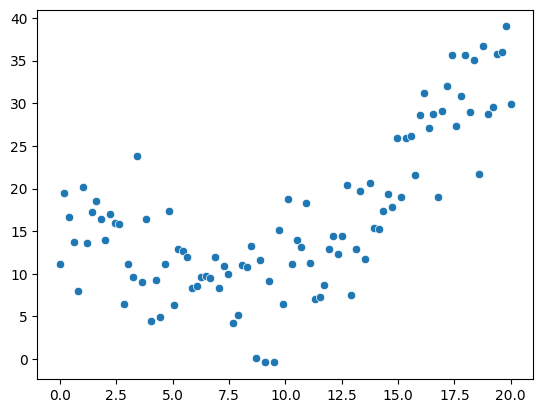

In [8]:
sns.scatterplot(x=x1[:,0], y=y[:,0])

Scikit-learn has a function `train_test_split` to spilt our data into a training set and testing set. To use it, we first need to import it.

In [9]:
from sklearn.model_selection import train_test_split

Now we can use it to automatically randomly split our data into two sets:
- A training set (used to train the models)
- A testing set (used to evaluate how the model generalizes)

The `train_test_split` function let's you select what proportion of the data will be used for testing. The rest will be put in the training set. A good rule of thumb is to use about 80\% of your data for training and 20\% of the data for testing.

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x1,
    y,
    test_size=0.2,
    random_state=2026
)

In [15]:
print(x1.shape)
print(y.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(100, 1)
(100, 1)
(80, 1)
(20, 1)
(80, 1)
(20, 1)


Now let's create four different models (degree 1, degree 2, degree 3, and degree 15).

To ensure that the features stay roughly the same size, we normalize them.

In [18]:
model1 = LinearRegression() # linear
model2 = LinearRegression() # quadratic
model3 = LinearRegression() # degree 3
model15 = LinearRegression() # degree 15

In [22]:
# Create feature matrices for the higher degree models
x_train2 = np.column_stack([x_train[:,0], x_train[:,0]**2])
x_train3 = np.column_stack([x_train[:,0], x_train[:,0]**2, x_train[:,0]**3])
x_train15 = np.column_stack([0.1**i * x_train[:,0]**i for i in range(1, 16)]) # 0.1**i is to keep features about the same size

# Create feature matrices for the higher degree models
x_test2 = np.column_stack([x_test[:,0], x_test[:,0]**2])
x_test3 = np.column_stack([x_test[:,0], x_test[:,0]**2, x_test[:,0]**3])
x_test15 = np.column_stack([0.1**i * x_test[:,0]**i for i in range(1, 16)]) # 0.1**i is to keep features about the same size

In [20]:
# Train each model with it's respective features
model1.fit(x_train, y_train)
model2.fit(x_train2, y_train)
model3.fit(x_train3, y_train)
model15.fit(x_train15, y_train)

LinearRegression()

In [21]:
# Get Predicted values on training set for each model
y_pred_train1 = model1.predict(x_train)
y_pred_train2 = model2.predict(x_train2)
y_pred_train3 = model3.predict(x_train3)
y_pred_train15 = model15.predict(x_train15)

In [23]:
# Get Predicted values on testing set for each model
y_pred_test1 = model1.predict(x_test)
y_pred_test2 = model2.predict(x_test2)
y_pred_test3 = model3.predict(x_test3)
y_pred_test15 = model15.predict(x_test15)

In [24]:
# Compute MSE for each model on training set
mse_train1 = mean_squared_error(y_pred_train1, y_train)
mse_train2 = mean_squared_error(y_pred_train2, y_train)
mse_train3 = mean_squared_error(y_pred_train3, y_train)
mse_train15 = mean_squared_error(y_pred_train15, y_train)

# Compute MSE for each model on testing set
mse_test1 = mean_squared_error(y_pred_test1, y_test)
mse_test2 = mean_squared_error(y_pred_test2, y_test)
mse_test3 = mean_squared_error(y_pred_test3, y_test)
mse_test15 = mean_squared_error(y_pred_test15, y_test)

In [25]:
print("Training MSE")
print(mse_train1)
print(mse_train2)
print(mse_train3)
print(mse_train15)

print("\nTesting MSE")
print(mse_test1)
print(mse_test2)
print(mse_test3)
print(mse_test15)

Training MSE
46.35339756004045
21.759136562151895
21.65580290396001
17.97693549709935

Testing MSE
59.71299895721775
15.240856749664141
15.434207182678922
20.620935180044405


We see that the degree 15 model does best on the training set. However, the degree 2 and degree 3 models did better on the test set.  Thus, we would say the degree 2 or degree 3 model is the best.